# Linear & Polynomial Regression (Analytic)

We will explore **linear regression** and **polynomial regression** using a synthetic dataset (`synthetic_regression.csv` with columns `x, y`). All solutions must use **analytic (closed-form)** formulas — **no gradient descent, no library `.fit()`** methods. Implement everything directly in **NumPy**.

## Tasks
1. **70/30 Train–Test Split (Unregularized)**
   - Split the data into 70% train / 30% test (random, reproducible).

   - Fit the following models:
     - Linear regression (polynomial degree 1),
     - Polynomial regression with degrees $k\in \{2, 5, 10, 15\}$.

   - For each model, build the design matrix explicitly:  For each datapoint, the row is given by

     $$\Phi(x) = [1, x, x^2, \dots, x^k].$$

     (let's call the design matrix $\Phi$ instead of $X$.)

   - Solve using the equations we derived in class:

     $$\mathbf{\theta}^* = (\Phi^\top\Phi)^{-1}\Phi^\top \mathbf{y}.$$

   - Compute **training error** and **test error**.

   - Plot (a) the dataset points with all model fits on one figure, and (b) a **bar chart** of training vs test errors.

2. **10-Fold Cross-Validation (Unregularized)**
   - Implement 10-fold CV yourself (shuffle indices once, split into folds).

   - For each degree {1, 2, 5, 10, 15}, compute the **average test error** across folds.

   - Plot a **bar chart** comparing the average test error across all models. Conclude the best hypothesis class.

3. **Repeat (1) and (2) with Ridge Regularization**.
   - Use ridge regression with: $$\mathbf{\theta}^*_\lambda = (\Phi^\top\Phi + \lambda I)^{-1}\Phi^\top \mathbf{y}.$$

   - **Take $\lambda = 1$** (fixed).

   - Show the same plots: fitted curves, bar chart of train/test errors, and bar chart of 10-fold average test errors.

### Notes
- If any bar chart scale makes some bars invisible, **use a logarithmic y-axis**: `plt.yscale("log")`.
- Keep your code structured and use the provided skeleton below.



## Functions to Implement

For this assignment, you will write the following functions yourself.  
Each function connects the mathematical definition we studied in class to working NumPy code. 

---

## 1. `design_matrix_poly_1d(x_column, degree, include_bias=True)`
- Build the design matrix **Φ** for **polynomial regression**:  
  \[
  $\Phi(x) = [1, x, x^2, \dots, x^k]$
  \]
- **Input:** vector of $x$-values, degree \(k\).  
- **Output:** design matrix of shape $(n \times (k+1)$.  

---

## 2. `normal_equation(Phi, y)`
- Compute the **closed-form OLS solution**:  
  \[
  $\theta^* = (\Phi^\top \Phi)^{-1} \Phi^\top \mathbf{y}$
  \]
  (or use the pseudoinverse if singular).  
- **Input:** design matrix $\Phi$, targets $\mathbf{y}$.  
- **Output:** regression coefficient vector $\mathbf{\theta}$.  

---

### 3. `ridge_closed_form(Phi, y, lam)`
- Compute the **ridge regression** solution:  
  \[
  $\theta^*_\lambda = (\Phi^\top \Phi + \lambda I)^{-1} \Phi^\top \mathbf{y}$
  \]
- **Input:** design matrix $\Phi$, targets $\mathbf{y}$, regularization parameter $\lambda$.  
- **Output:** coefficient vector $\mathbf{\theta}$.  

---

### 4. `predict(Phi, theta)`
- Generate predictions:  
  \[
  $\hat{\mathbf{y}} = \Phi \mathbf{\theta}$
  \]
- **Input:** design matrix $\Phi$, coefficients $\mathbf{\theta}$.  
- **Output:** predicted values.  

---

### 5. `err(y_true, y_pred)`
- Compute the **average squared error**:  
  \[
  $\text{Error} = \frac{1}{n} \sum_i (y_i - \hat{y}_i)^2$ 
  \]
- **Input:** true values $\mathbf{y}$, predicted values $\mathbf{\hat{y}}$.  
- **Output:** scalar error.  

---


## Functions to use:

You can use the following functions for reading the data, doing the test-train split and also for the k-fold CV.
### 6. `kfold_indices(n, K, seed=0)`
- Generate index splits for **K-fold cross-validation**.  
- **Input:** dataset size \(n\), number of folds \(K\), optional random seed.  
- **Output:** list of `train_idx` and `val_idx` pairs.  

---

### 7. `train_test_split_indices(n, test_ratio=0.3, seed=42)`
- Randomly split dataset into **training** and **test** sets.  
- **Input:** dataset size \(n\), test ratio, optional random seed.  
- **Output:** two arrays: `train_idx`, `test_idx`.  

---

### 8. `load_csv_xy(path)`
- Load a CSV file with columns **`x`** and **`y`**.  
- **Output:**  
  - \(X\): array of shape \(n \times 1\),  
  - \(y\): vector of shape \(n\).  

---
  




  


## Starter Skeleton (fill the TODOs)
Update the CSV path to where you saved `synthetic_regression.csv`.


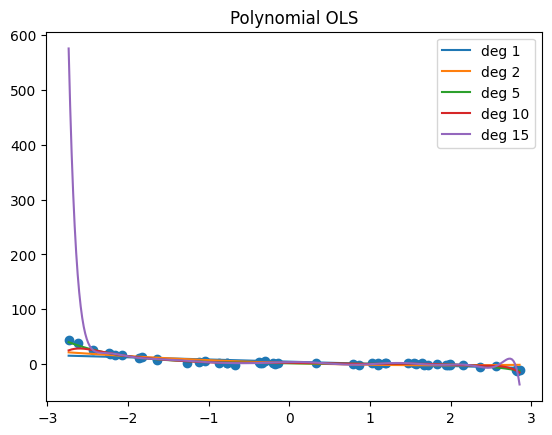

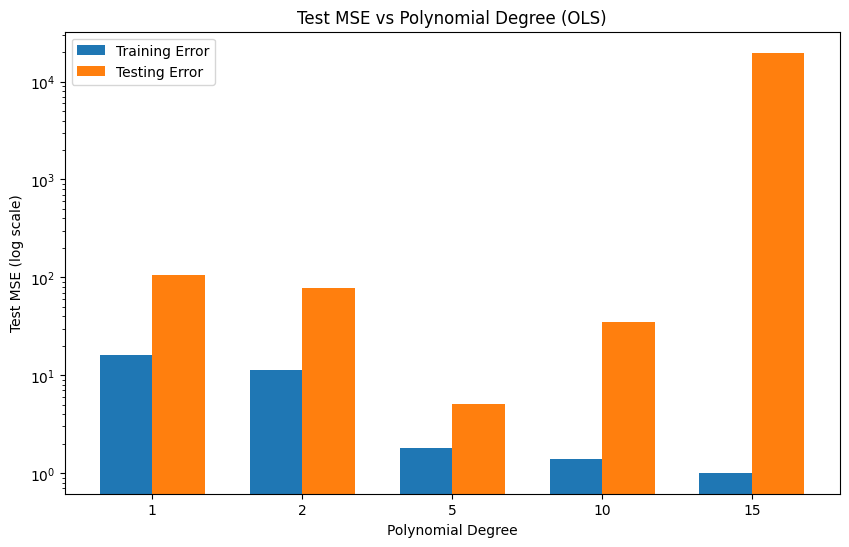

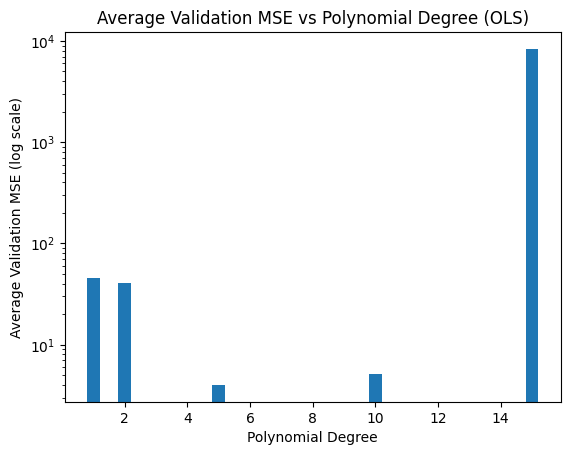

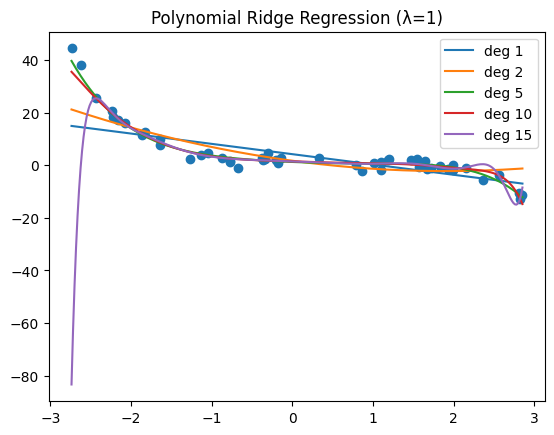

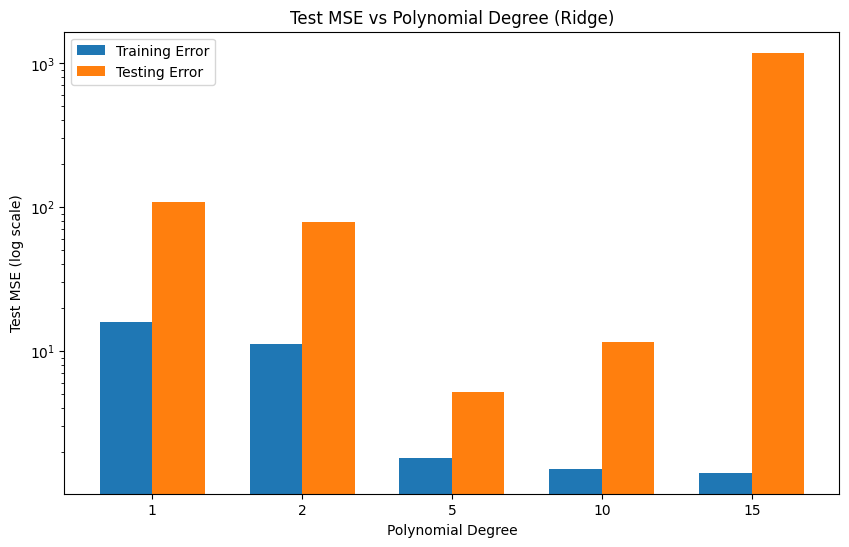

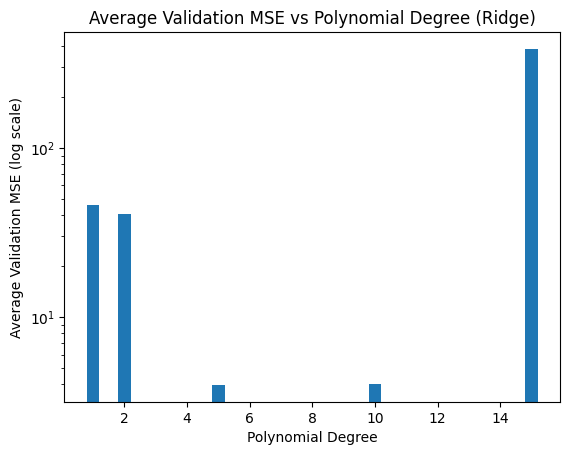

In [ ]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import math

def design_matrix_poly_1d(x_column: np.ndarray, degree: int, include_bias: bool=True) -> np.ndarray:
    """Return Vandermonde-style design matrix [1, x, x^2, ..., x^degree]."""
    if include_bias: # include the intercept term
        design_matrix = np.vander(x_column.flatten(), N=degree + 1, increasing=True)
        return design_matrix
    else:
        # Exclude the bias i.e. the intercept term in the first column
        design_matrix = np.vander(x_column.flatten(), N=degree + 1, increasing=True)[:, 1:]
        return design_matrix


def normal_equation(Phi: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Closed-form least squares: theta = (Phi^T Phi)^{-1} Phi^T y."""
    if np.linalg.det(Phi.T @ Phi) == 0:
        # If matrix is singular, use pseudo-inverse
        optimal_theta = np.linalg.pinv(Phi.T @ Phi) @ Phi.T @ y
        return optimal_theta
    else: # otherwise use nomral equation
        optimal_theta = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y
        return optimal_theta

def ridge_closed_form(Phi: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    """Closed-form ridge: theta = (Phi^T Phi + λI)^{-1} Phi^T y."""
    # Create identity matrix with the same number of colunms as Phi
    I = np.eye(Phi.shape[1])
    if np.linalg.det(Phi.T @ Phi + lam * I) == 0:
        # If matrix is singular, use pseudo-inverse
        optimal_theta = np.linalg.pinv(Phi.T @ Phi + lam * I) @ Phi.T @ y
        return optimal_theta
    else: # otherwise use nomral equation
        optimal_theta = np.linalg.inv(Phi.T @ Phi + lam * I) @ Phi.T @ y
        return optimal_theta


def predict(Phi: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """Predict y values given design matrix and model parameters."""
    y_pred =  Phi @ theta
    return y_pred



def err(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Compute mean squared error."""
    square_err = (y_true - y_pred) ** 2
    return np.mean(square_err)


def kfold_indices(n: int, K: int, seed: int = 0):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, K)
    splits = []
    for i in range(K):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(K) if j != i])
        splits.append((train_idx, val_idx))
    return splits

def train_test_split_indices(n: int, test_ratio: float = 0.3, seed: int = 42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    n_test = int(round(test_ratio * n))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return train_idx, test_idx

def load_csv_xy(path: str):
    xs, ys = [], []
    with open(path, "r") as f:
        rd = csv.DictReader(f)
        for row in rd:
            xs.append(float(row["x"]))
            ys.append(float(row["y"]))
    X = np.array(xs).reshape(-1, 1)
    y = np.array(ys)
    return X, y


if __name__ == "__main__":
    # load data
    X, y = load_csv_xy("synthetic_regression.csv")
    # linear & polynomial models
    degrees = [1, 2, 5, 10, 15]


    # 1. 70/30 train test split unregularized
    # -----------------------------------------------------
    # get train v test split
    train_idx, test_idx = train_test_split_indices(X.shape[0], test_ratio=0.3, seed=42)
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    mse_train_list = []
    mse_test_list = []
    thetas = []
    for degree in degrees:
        # create design matrix
        Phi_train = design_matrix_poly_1d(X_train, degree, include_bias=True)
        Phi_test = design_matrix_poly_1d(X_test, degree, include_bias=True)
        # normal equation
        theta_normal = normal_equation(Phi_train, y_train)
        # evaluate on train set
        y_train_pred_normal = predict(Phi_train, theta_normal)
        mse_train = err(y_train, y_train_pred_normal)
        mse_train_list.append(mse_train)
        # evaluate on test set
        y_test_pred_normal = predict(Phi_test, theta_normal)
        mse_test = err(y_test, y_test_pred_normal)
        mse_test_list.append(mse_test)
        thetas.append(theta_normal)
    
    # plot a. dataset points with all model fits 
    xs = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

    plt.scatter(X, y)
    for degree, theta in zip(degrees, thetas):
        Phi = design_matrix_poly_1d(xs, degree)
        plt.plot(xs, predict(Phi, theta), label=f"deg {degree}")

    title = "Polynomial OLS"
    plt.title(title)    
    plt.legend()
    plt.show()

    # plot b. degree vs test MSE
    x = np.arange(len(degrees))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, mse_train_list, width, label="Training Error")
    plt.bar(x + width/2, mse_test_list, width, label="Testing Error")
    plt.yscale("log")
    plt.xticks(x, [str(i) for i in degrees])
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Test MSE (log scale)")
    plt.legend()
    plt.title("Test MSE vs Polynomial Degree (OLS)")
    plt.show()

    # 2. 10 fold cross validation unregularized
    # -----------------------------------------------------

    K = 10
    splits = kfold_indices(X.shape[0], K=K, seed=42)
    avg_mse_per_degree = []
    degree_mse = {degree: [] for degree in degrees}
    for fold, (train_idx, val_idx) in enumerate(splits):
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]
        for degree in degrees:
            # create design matrix
            Phi_train = design_matrix_poly_1d(X_train, degree, include_bias=True)
            Phi_val = design_matrix_poly_1d(X_val, degree, include_bias=True)
            # normal equation
            theta_normal = normal_equation(Phi_train, y_train)
            # evaluate on validation set
            y_val_pred_normal = predict(Phi_val, theta_normal)
            mse_val = err(y_val, y_val_pred_normal)
            degree_mse[degree].append(mse_val) 
    # average mse per degree
    for degree in degrees:
        avg_mse = np.mean(degree_mse[degree])
        avg_mse_per_degree.append(avg_mse)
    # plot bar chart comparing test error 
    plt.bar(degrees, avg_mse_per_degree, width=0.4)
    plt.yscale("log")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Average Validation MSE (log scale)")
    plt.title("Average Validation MSE vs Polynomial Degree (OLS)")
    plt.show()



    # 3.1. 70/30 train test split ridge regression
    # -----------------------------------------------------

    # get train test split
    train_idx, test_idx = train_test_split_indices(X.shape[0], test_ratio=0.3, seed=42)
    X_train, y_train = X[train_idx],    y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]   

    degrees = [1, 2, 5, 10, 15]
    lamda = 1
    mse_train_list_ridge = []
    mse_test_list_ridge = []
    thetas_ridge = []
    for degree in degrees:
        # create design matrix
        Phi_train = design_matrix_poly_1d(X_train, degree, include_bias=True)
        Phi_test = design_matrix_poly_1d(X_test, degree, include_bias=True)
        # ridge closed form
        theta_ridge = ridge_closed_form(Phi_train, y_train, lam=lamda)
        # evaluate on train set
        y_train_pred_ridge = predict(Phi_train, theta_ridge)
        mse_train_ridge = err(y_train, y_train_pred_ridge)
        mse_train_list_ridge.append(mse_train_ridge)
        # evaluate on test set
        y_test_pred_ridge = predict(Phi_test, theta_ridge)
        mse_test_ridge = err(y_test, y_test_pred_ridge)
        mse_test_list_ridge.append(mse_test_ridge)
        thetas_ridge.append(theta_ridge)

    # plot a. dataset points with all model fits
    xs = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    plt.scatter(X, y)
    for degree, theta in zip(degrees, thetas_ridge):
        Phi = design_matrix_poly_1d(xs, degree)
        plt.plot(xs, predict(Phi, theta), label=f"deg {degree}")
    title = "Polynomial Ridge Regression (lambda=1)"
    plt.title(title)    
    plt.legend()
    plt.show()

    # plot b. degree vs test MSE
    x = np.arange(len(degrees))  
    width = 0.35                 
    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, mse_train_list_ridge, width, label="Training Error")
    plt.bar(x + width/2, mse_test_list_ridge, width, label="Testing Error")
    plt.yscale("log")
    plt.xticks(x, [str(i) for i in degrees])
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Test MSE (log scale)")
    plt.legend()
    plt.title("Test MSE vs Polynomial Degree (Ridge)")
    plt.show()

    # 3.2. 10 fold cross validation ridge regression
    # -----------------------------------------------------

    K = 10
    splits = kfold_indices(X.shape[0], K=K, seed=42)
    avg_mse_per_degree_ridge = []
    degree_mse_ridge = {degree: [] for degree in degrees}
    for fold, (train_idx, val_idx) in enumerate(splits):        
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]
        for degree in degrees:
            # create design matrix
            Phi_train = design_matrix_poly_1d(X_train, degree, include_bias=True)
            Phi_val = design_matrix_poly_1d(X_val, degree, include_bias=True)
            # ridge closed form
            theta_ridge = ridge_closed_form(Phi_train, y_train, lam=lamda)
            # evaluate on validation set
            y_val_pred_ridge = predict(Phi_val, theta_ridge)
            mse_val_ridge = err(y_val, y_val_pred_ridge)
            degree_mse_ridge[degree].append(mse_val_ridge) 
    # average mse per degree
    for degree in degrees:
        avg_mse_ridge = np.mean(degree_mse_ridge[degree])
        avg_mse_per_degree_ridge.append(avg_mse_ridge)
    # plot bar chart comparing test error 
    plt.bar(degrees, avg_mse_per_degree_ridge, width=0.4)
    plt.yscale("log")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Average Validation MSE (log scale)")
    plt.title("Average Validation MSE vs Polynomial Degree (Ridge)")
    plt.show()      
    